# MiBiReMo Example: Laboratory column test

A soil column 30 cm long, with an inner diameter of 5 cm, is flushed from the bottom at 1 mL/min with a solution
containing two pseudo-components: a conservative tracer (Tr) and a solute degraded with first-order kinetics (Dk), both
at 1 mmol/kgw. After 10 h the flow is stopped for 6 h (stop-flow test), then restarted. During the stop the degradable
solute keeps reacting in the pore water, while the tracer only diffuses: the effluent after the restart shows the
degradation as a drop of Dk.

The class `ColumnModel` computes the advection and dispersion using the semi-Lagrangian solver (`SemiLagSolver`), 
and the reactions with PHREEQC (PhreeqcRM), coupled sequentially at every time step.

In [1]:
import math
from importlib.resources import files
from pathlib import Path
import matplotlib.pyplot as plt
import mibiremo as mb

MINUTE, HOUR = 60.0, 3600.0
OUTPUT = (Path(__file__).parent if "__file__" in globals() else Path()) / "output"  # next to this script or notebook
OUTPUT.mkdir(exist_ok=True)

## PHREEQC database

Kinetic rates must be defined in the RATES block of the database. Here phreeqc.dat is extended with two elements, Tr
and Dk (gram formula weight 1), and a rate "Dk" for first-order decay, r = λ C, with λ = PARM(1) [s⁻¹].

In [2]:
definitions = """
SOLUTION_MASTER_SPECIES
Tr       Tr       0     Tr     1.0
Dk       Dk       0     Dk     1.0
SOLUTION_SPECIES
Tr = Tr
    log_k 0
Dk = Dk
    log_k 0
RATES
Dk
-start
10 SAVE PARM(1) * TOT("Dk") * TIME
-end
"""
text = (files("mibiremo") / "database" / "phreeqc.dat").read_text(encoding="latin-1")
database = OUTPUT / "column.dat"
database.write_text(text.replace("\nEND\n", definitions + "END\n", 1), encoding="latin-1")

48571

## Model setup

The flow rate Q is a schedule [(t, value), ...] with t in seconds, as all the time-dependent inputs: 1 mL/min, 0
between 10 h and 16 h. Solution 1 is the initial pore water, solution 2 the influent. The KINETICS block 1 (decay of
Dk with a half-life of 2 h) acts in all cells. Concentrations are in mol/m³ (= mmol/L).

In [3]:
flow_rate = 1e-6 / MINUTE  # 1 mL/min in m3/s
half_life = 2 * HOUR
model = mb.ColumnModel(
    workspace=OUTPUT / "column_reactive_transport_test",
    length=0.3,
    diameter=0.05,
    porosity=0.38,
    flow_rate=[(0.0, flow_rate), (10 * HOUR, 0.0), (16 * HOUR, flow_rate)],
    longitudinal_dispersivity=0.005,  # m
    diffusion_coefficient=1e-9,  # m2/s
    n_cells=60,
    simulation_time=30 * HOUR,
    time_step=5 * MINUTE,
    database=database,
    solutions={1: {}, 2: {"Tr": 1e-3, "Dk": 1e-3}},  # mol/kgw
    initial_solution=1,
    influent_solution=2,
    kinetics={1: {"Dk": {"m0": 1.0, "parms": [math.log(2) / half_life], "formula": "Dk -1"}}},
    initial_kinetics=1,
)
print(model.stress_periods)
velocity = flow_rate / (model.porosity * math.pi * model.diameter**2 / 4)
print(
    f"Pore volume {model.pore_volume * 1e6:.0f} mL, pore-water velocity {velocity * 86400:.2f} m/d, "
    f"travel time through the column {model.length / velocity / HOUR:.1f} h"
)

     start  duration  n_time_steps     flow_rate  influent_solution
0      0.0   36000.0           120  1.666667e-08                  2
1  36000.0   21600.0            72  0.000000e+00                  2
2  57600.0   50400.0           168  1.666667e-08                  2
Pore volume 224 mL, pore-water velocity 1.93 m/d, travel time through the column 3.7 h


## Simulation

All PHREEQC components are transported, i.e., H, O, charge balance, and the elements of the solutions.

In [11]:
model.run()
print("Components:", model.components)

Components: [np.str_('H'), np.str_('O'), np.str_('Charge'), np.str_('Dk'), np.str_('Tr')]


## Breakthrough curves

The effluent concentration is that of the last cell. With the flow, Dk reaches a steady state below the influent
concentration, set by the travel time and the half-life.

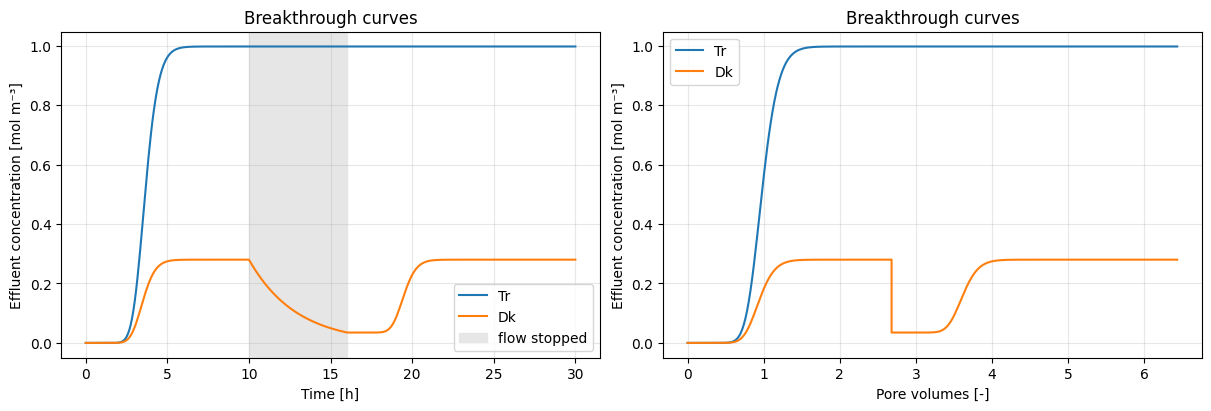

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
for component in ["Tr", "Dk"]:
    effluent = model.effluent(component)
    axes[0].plot(effluent["time"] / HOUR, effluent["concentration"], label=component)
    axes[1].plot(effluent["pore_volumes"], effluent["concentration"], label=component)
axes[0].axvspan(10, 16, color="0.9", label="flow stopped")
axes[0].set(xlabel="Time [h]", ylabel="Effluent concentration [mol m⁻³]", title="Breakthrough curves")
axes[1].set(xlabel="Pore volumes [-]", ylabel="Effluent concentration [mol m⁻³]", title="Breakthrough curves")
for ax in axes:
    ax.grid(alpha=0.3)
    ax.legend()
plt.show()

## Concentration profiles

The tracer fills the column after about 1.5 pore volumes. During the stop Dk
decays by a factor 2^(6 h / 2 h) = 8, except near the inlet, where the influent diffuses into the column.

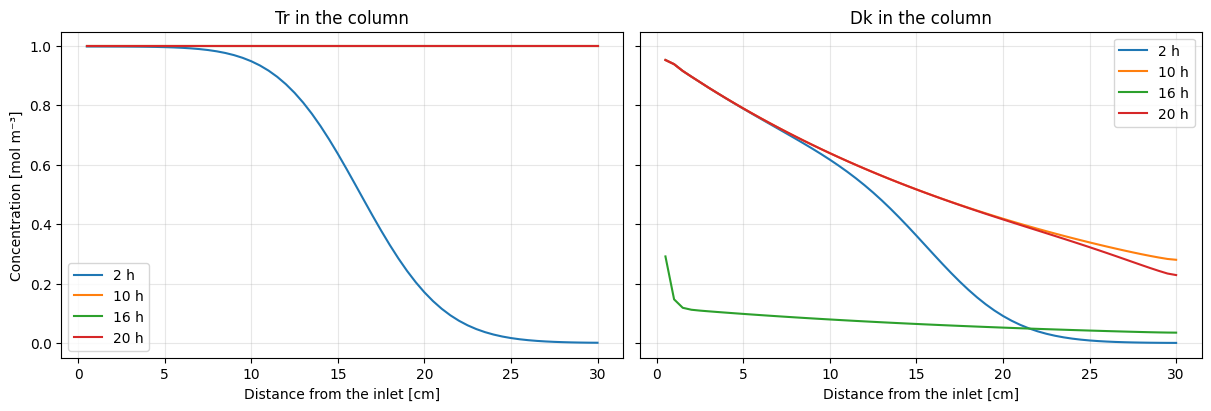

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout="constrained", sharey=True)
for ax, component in zip(axes, ["Tr", "Dk"]):
    for hours in [2, 10, 16, 20]:
        ax.plot(model.x * 100, model.concentration(component, hours * HOUR), label=f"{hours} h")
    ax.set(xlabel="Distance from the inlet [cm]", title=f"{component} in the column")
    ax.grid(alpha=0.3)
    ax.legend()
axes[0].set_ylabel("Concentration [mol m⁻³]")
plt.show()